Epoch 1/60 | Train Loss: 3.3634 | Val Loss: 2.2027 | Top-1: 69.68% | Top-5: 91.05%
New best model saved with Top-1: 69.68%
Epoch 2/60 | Train Loss: 2.4520 | Val Loss: 1.3734 | Top-1: 83.17% | Top-5: 96.66%
New best model saved with Top-1: 83.17%
Epoch 3/60 | Train Loss: 2.3863 | Val Loss: 1.2598 | Top-1: 86.01% | Top-5: 97.40%
New best model saved with Top-1: 86.01%
Epoch 4/60 | Train Loss: 2.4283 | Val Loss: 1.2445 | Top-1: 86.10% | Top-5: 97.50%
New best model saved with Top-1: 86.10%
Epoch 5/60 | Train Loss: 2.4941 | Val Loss: 1.2505 | Top-1: 85.62% | Top-5: 97.31%
Epoch 6/60 | Train Loss: 2.5301 | Val Loss: 1.2565 | Top-1: 85.34% | Top-5: 97.18%
Epoch 7/60 | Train Loss: 2.4765 | Val Loss: 1.2479 | Top-1: 85.45% | Top-5: 97.15%
Epoch 8/60 | Train Loss: 2.4249 | Val Loss: 1.2278 | Top-1: 86.07% | Top-5: 97.27%
Epoch 9/60 | Train Loss: 2.3596 | Val Loss: 1.2142 | Top-1: 86.22% | Top-5: 97.33%
New best model saved with Top-1: 86.22%
Epoch 10/60 | Train Loss: 2.3314 | Val Loss: 1.2020 |

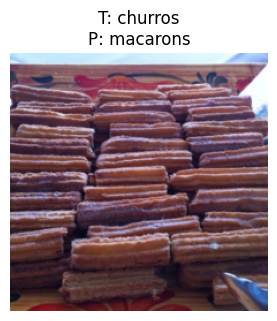

d:\Personal_projects\Pyhton_proj\AI-Food-Recognition-Nutrition-Assistant\venv\Lib\site-packages\torch\nn\modules\module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


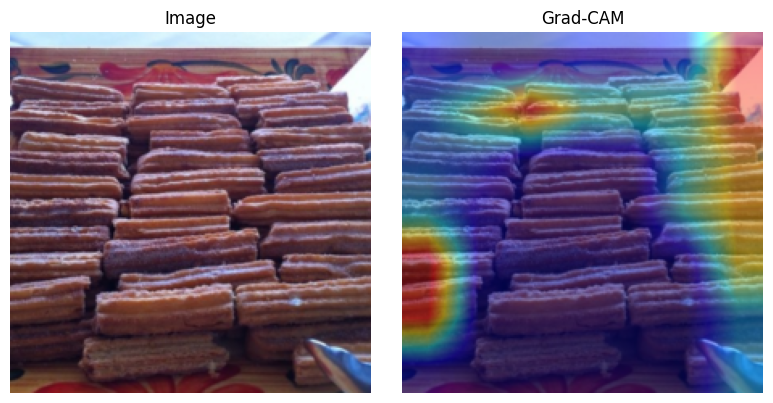

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import transforms, models
from torchvision.datasets import Food101
from torch.utils.data import DataLoader
from torchvision.transforms import RandAugment
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import cv2

# ----------------- CONFIG -----------------
data_root = "data"
save_dir = "checkpoints"
best_model_path = os.path.join(save_dir, "best_convnext_tiny.pth")

num_classes = 101
batch_size = 32
num_workers = 4
epochs = 60
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

lr_backbone = 3e-5
lr_head = 5e-4
weight_decay = 1e-4

max_lr = 5e-4
pct_start = 0.1
div_factor = 25
final_div_factor = 1e4

label_smoothing = 0.1
patience = 8

use_mixup = True
use_cutmix = True
mixup_alpha = 0.2
cutmix_alpha = 1.0
mixup_cutmix_prob = 0.5

use_ema = True
ema_decay = 0.999

randaugment_num_ops = 2
randaugment_magnitude = 9
random_erasing_p = 0.25

# ----------------- UTILS -----------------
def set_seed(s=42):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append((correct_k, batch_size))
    return res

def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    return np.clip(img, 0, 1)

def show_misclassified(images, labels, preds, class_names, max_images=8):
    idxs = (labels != preds).nonzero()[0].tolist()
    idxs = idxs[:max_images]
    if len(idxs) == 0:
        print("No misclassified samples in this batch.")
        return
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(idxs):
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        img = denormalize(img)
        true_label = class_names[labels[idx].item()]
        pred_label = class_names[preds[idx].item()]
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.tight_layout()
    plt.show()

# ----------------- MIXUP / CUTMIX -----------------
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = (1. - lam) ** 0.5
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = random.randint(0, W)
    cy = random.randint(0, H)
    x1 = max(cx - cut_w // 2, 0)
    y1 = max(cy - cut_h // 2, 0)
    x2 = min(cx + cut_w // 2, W)
    y2 = min(cy + cut_h // 2, H)
    return x1, y1, x2, y2

def mixup_data(x, y, alpha=mixup_alpha):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=cutmix_alpha):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    y_a, y_b = y, y[index]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

def mixup_cutmix_criterion(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)

def apply_mixup_cutmix(x, y):
    if not (use_mixup or use_cutmix):
        return x, y, y, 1.0, False
    if random.random() < mixup_cutmix_prob:
        if use_mixup and use_cutmix:
            if random.random() < 0.5:
                x, y_a, y_b, lam = mixup_data(x, y)
            else:
                x, y_a, y_b, lam = cutmix_data(x, y)
        elif use_mixup:
            x, y_a, y_b, lam = mixup_data(x, y)
        else:
            x, y_a, y_b, lam = cutmix_data(x, y)
        return x, y_a, y_b, lam, True
    return x, y, y, 1.0, False

# ----------------- EMA -----------------
class ModelEMA:
    def __init__(self, model, decay=ema_decay, device=None):
        import copy
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        self.device = device
        if self.device is not None:
            self.ema.to(self.device)
        for p in self.ema.parameters():
            p.requires_grad_(False)

    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            for k, v in self.ema.state_dict().items():
                if v.dtype.is_floating_point:
                    v.copy_(v * self.decay + msd[k].detach() * (1. - self.decay))

# ----------------- GRAD-CAM -----------------
def get_last_conv_layer(model):
    return model.features[-1]

class GradCAM:
    def __init__(self, model, target_layer=None):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer or get_last_conv_layer(model)
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1)
        loss = F.nll_loss(F.log_softmax(output, dim=1), target_class)
        loss.backward()
        grads = self.gradients
        acts = self.activations
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def overlay_cam_on_image(img, cam):
    h, w, _ = img.shape
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = heatmap[:, :, ::-1] / 255.0
    overlay = 0.4 * heatmap + 0.6 * img
    overlay = np.clip(overlay, 0, 1)
    return overlay

# ----------------- DATA -----------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=randaugment_num_ops, magnitude=randaugment_magnitude),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=random_erasing_p,
                             scale=(0.02, 0.2),
                             ratio=(0.3, 3.3))
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def get_dataloaders():
    train_data = Food101(root=data_root, split="train",
                         transform=train_transform, download=True)
    test_data = Food101(root=data_root, split="test",
                        transform=test_transform, download=True)
    train_loader = DataLoader(train_data, batch_size=batch_size,
                              shuffle=True, num_workers=num_workers,
                              pin_memory=True, prefetch_factor=4)
    test_loader = DataLoader(test_data, batch_size=batch_size,
                             shuffle=False, num_workers=num_workers,
                             pin_memory=True, prefetch_factor=4)
    return train_loader, test_loader, train_data.classes

# ----------------- MODEL -----------------
def get_model():
    model = models.convnext_tiny(weights="IMAGENET1K_V1")
    model.classifier[2] = nn.Linear(768, num_classes)
    return model

# ----------------- TRAIN / VAL -----------------
def train_one_epoch(model, ema_model, train_loader, optimizer, scheduler,
                    criterion, scaler, device):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        imgs_mix, y_a, y_b, lam, mixed = apply_mixup_cutmix(imgs, labels)
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(imgs_mix)
            if mixed:
                loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        if ema_model is not None:
            ema_model.update(model)
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device, use_ema=False, ema_model=None):
    if use_ema and ema_model is not None:
        eval_model = ema_model.ema
    else:
        eval_model = model
    eval_model.eval()
    total_loss = 0
    correct1_total = 0
    correct5_total = 0
    num_samples = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                outputs = eval_model(imgs)
                loss = criterion(outputs, labels)
            total_loss += loss.item()
            (correct1, batch_size), (correct5, _) = accuracy(outputs, labels, topk=(1, 5))
            correct1_total += correct1.item()
            correct5_total += correct5.item()
            num_samples += batch_size
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(val_loader)
    top1 = 100.0 * correct1_total / num_samples
    top5 = 100.0 * correct5_total / num_samples
    return avg_loss, top1, top5, all_labels, all_preds

# ----------------- MAIN -----------------
def main():
    set_seed(seed)
    ensure_dir(save_dir)

    train_loader, test_loader, class_names = get_dataloaders()
    model = get_model().to(device)

    ema_model = ModelEMA(model, decay=ema_decay, device=device) if use_ema else None

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    optimizer = AdamW([
        {"params": model.features.parameters(), "lr": lr_backbone},
        {"params": model.classifier.parameters(), "lr": lr_head}
    ], weight_decay=weight_decay)

    steps_per_epoch = len(train_loader)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=max_lr,
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        pct_start=pct_start,
        div_factor=div_factor,
        final_div_factor=final_div_factor
    )

    scaler = torch.amp.GradScaler(device="cuda")

    best_acc = 0.0
    wait = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model, ema_model, train_loader, optimizer, scheduler,
            criterion, scaler, device
        )
        val_loss, top1, top5, all_labels, all_preds = validate(
            model, test_loader, criterion, device,
            use_ema=use_ema, ema_model=ema_model
        )
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Top-1: {top1:.2f}% | Top-5: {top5:.2f}%")
        if top1 > best_acc:
            best_acc = top1
            wait = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved with Top-1: {best_acc:.2f}%")
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    print(f"Best Top-1 Accuracy: {best_acc:.2f}%")

    # Final metrics
    _, _, _, all_labels, all_preds = validate(
        model, test_loader, criterion, device,
        use_ema=use_ema, ema_model=ema_model
    )
    print(classification_report(all_labels, all_preds, target_names=class_names))
    conf_mat = confusion_matrix(all_labels, all_preds)
    print("Confusion matrix shape:", conf_mat.shape)

    # Optional: show some misclassified examples
    # (run one batch through model and visualize)
    model.eval()
    with torch.no_grad():
        imgs, labels = next(iter(test_loader))
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
    show_misclassified(imgs.cpu(), labels.cpu(), preds.cpu(), class_names)

    # Optional: Grad-CAM on first image
    gradcam = GradCAM(model)
    img0 = imgs[0:1]
    cam = gradcam.generate(img0)
    img_np = denormalize(img0[0].permute(1, 2, 0).cpu().numpy())
    overlay = overlay_cam_on_image(img_np, cam)
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1); plt.imshow(img_np); plt.axis("off"); plt.title("Image")
    plt.subplot(1, 2, 2); plt.imshow(overlay); plt.axis("off"); plt.title("Grad-CAM")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


In [2]:
from torch.utils.tensorboard import SummaryWriter

# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('runs/food-101_experiment_1')

: 